In [5]:
import math
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


class ResonantRNN(nn.Module):

    def __init__(self, hidden_size=64, r=0.5, prediction_length=20):
        super().__init__()

        self.hidden_size = hidden_size
        self.r = r
        self.prediction_length = prediction_length

        # Sampling frequency and resonant frequency of each node (Hz)
        Fs = 1000
        freqs = torch.linspace(5, 40, hidden_size)

        # History-dependent coefficients (fixed, not trained)
        self.register_buffer("alpha1", 2 * r * torch.cos(2 * math.pi * freqs / Fs))
        self.register_buffer("alpha2", torch.full((hidden_size,), -r**2))

        # Node -> node coupling, small random init
        self.W = nn.Parameter(
            torch.empty(hidden_size, hidden_size).uniform_(-0.05, 0.05)
        )

        # Mask that removes self-connections
        self.register_buffer("mask", 1 - torch.eye(hidden_size))

        # Final node state -> predicted segment
        self.output = nn.Linear(hidden_size, prediction_length)

    def forward(self, x):
        # x: (batch, T, 1), the same 1-D input is sent to every node

        batch_size = x.size(0)

        # Node activity at t-1 and t-2
        h_prev1 = torch.zeros(batch_size, self.hidden_size, device=x.device)
        h_prev2 = torch.zeros(batch_size, self.hidden_size, device=x.device)

        W = self.W * self.mask

        # Start at t = 2 because the model uses both t-1 and t-2
        for t in range(2, x.size(1)):

            x_t = x[:, t, :]                      # (batch, 1)

            # coupling[k] = sum_{j != k} W[k, j] * tanh(x_t * h_j[t-1])
            coupling = torch.tanh(x_t * h_prev1) @ W.T

            # Equation 3
            h = (
                self.alpha1 * h_prev1
                + self.alpha2 * h_prev2
                + x_t
                + coupling
            )

            h_prev2 = h_prev1
            h_prev1 = h

        # Predict the next segment
        y_pred = self.output(h_prev1)

        return y_pred

### Training Resonant RNN on Daily Minimum Temperatures Dataset

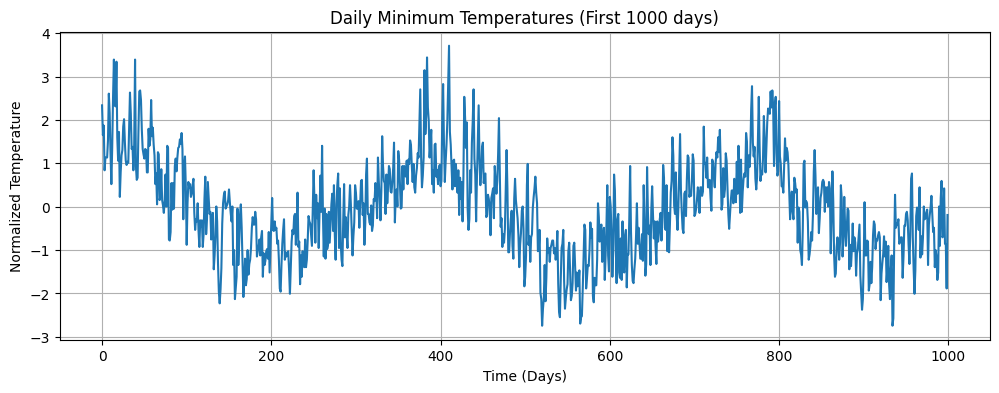

In [6]:
import pandas as pd

# Load the daily minimum temperatures dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
df_temp = pd.read_csv(url)

# Extract and normalize the temperatures
temp_values = df_temp["Temp"].values.astype(np.float32)
temp_mean = temp_values.mean()
temp_std = temp_values.std()
temp_normalized = (temp_values - temp_mean) / temp_std

# Plot the actual temperature dataset
plt.figure(figsize=(12, 4))
plt.plot(temp_normalized[:1000])
plt.xlabel("Time (Days)")
plt.ylabel("Normalized Temperature")
plt.title("Daily Minimum Temperatures (First 1000 days)")
plt.grid(True)
plt.show()

In [8]:
# Create segments for the temperature dataset
input_len = 50
pred_len = 20

X_temp = []
Y_temp = []

for t in range(input_len, len(temp_normalized) - pred_len):
    X_temp.append(temp_normalized[t - input_len : t])
    Y_temp.append(temp_normalized[t : t + pred_len])

X_temp = np.array(X_temp)
Y_temp = np.array(Y_temp)

X_temp_t = torch.tensor(X_temp, dtype=torch.float32).unsqueeze(-1)
Y_temp_t = torch.tensor(Y_temp, dtype=torch.float32)

# Split train/test (80/20)
split_idx = int(0.8 * len(X_temp_t))

X_temp_train = X_temp_t[:split_idx]
Y_temp_train = Y_temp_t[:split_idx]

X_temp_test = X_temp_t[split_idx:]
Y_temp_test = Y_temp_t[split_idx:]

temp_train_dataset = TensorDataset(X_temp_train, Y_temp_train)
temp_train_loader = DataLoader(temp_train_dataset, batch_size=64, shuffle=True)

print("Train size:", len(X_temp_train))
print("Test size:", len(X_temp_test))

Train size: 2864
Test size: 716


In [9]:
def train_temp_model(r_val, epochs=25):
    model = ResonantRNN(hidden_size=64, r=r_val, prediction_length=pred_len)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()

    for epoch in range(epochs):
        model.train()
        for batch_X, batch_Y in temp_train_loader:
            optimizer.zero_grad()
            predictions = model(batch_X)
            loss = loss_fn(predictions, batch_Y)
            loss.backward()
            optimizer.step()
    return model

# Sweeping many resonance values between 0.9 and 1.0
r_sweep = [0.90, 0.92, 0.94, 0.96, 0.98, 0.99, 0.995, 0.999]
temp_test_errors = []
temp_models = {}

for r in r_sweep:
    print(f"Training Resonant RNN with r = {r}...")
    model = train_temp_model(r)
    temp_models[r] = model

    # Evaluate performance
    model.eval()
    with torch.no_grad():
        predictions = model(X_temp_test)
        mse_loss = torch.mean((predictions - Y_temp_test) ** 2).item()

    temp_test_errors.append(mse_loss)
    print(f"r = {r:.3f} | Test MSE = {mse_loss:.5f}")

Training Resonant RNN with r = 0.9...
r = 0.900 | Test MSE = 0.69284
Training Resonant RNN with r = 0.92...
r = 0.920 | Test MSE = 0.59940
Training Resonant RNN with r = 0.94...
r = 0.940 | Test MSE = 0.74488
Training Resonant RNN with r = 0.96...
r = 0.960 | Test MSE = 0.81354
Training Resonant RNN with r = 0.98...
r = 0.980 | Test MSE = 1.29429
Training Resonant RNN with r = 0.99...
r = 0.990 | Test MSE = 1.35654
Training Resonant RNN with r = 0.995...
r = 0.995 | Test MSE = 1.53864
Training Resonant RNN with r = 0.999...
r = 0.999 | Test MSE = 3.97691


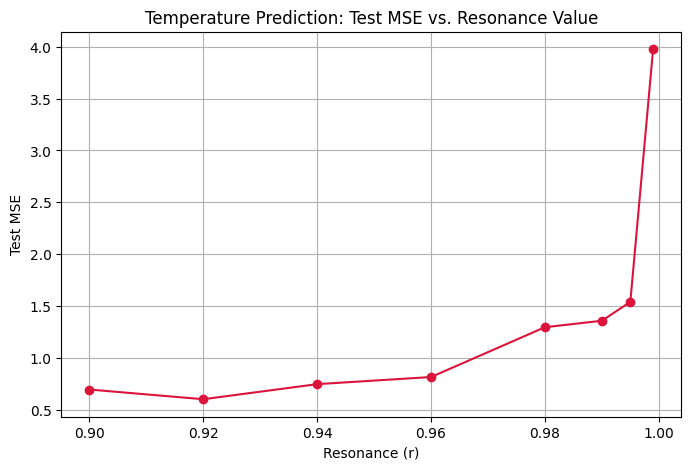

In [13]:
# Plot performance vs resonance values
plt.figure(figsize=(8, 5))
plt.plot(r_sweep, temp_test_errors, marker="o", color="crimson")
plt.xlabel("Resonance (r)")
plt.ylabel("Test MSE")
plt.title("Temperature Prediction: Test MSE vs. Resonance Value")
plt.grid(True)
plt.show()

### Wider Resonance Sweep ($r$ from 0 to 1)
We will now sweep $r$ across a wider spectrum from $0.0$ (no resonance, acting like a standard vanilla RNN transition) up to $0.999$ (near-total resonance) to map out how prediction accuracy behaves.

In [14]:
# Define a wide range of r values from 0.0 to nearly 1.0
r_wide_sweep = [0.0, 0.2, 0.4, 0.6, 0.8, 0.9, 0.95, 0.98, 0.99, 0.999]
wide_test_errors = []
wide_models = {}

for r in r_wide_sweep:
    print(f"Training Resonant RNN with r = {r}...")
    model = train_temp_model(r, epochs=25)
    wide_models[r] = model

    # Evaluate performance
    model.eval()
    with torch.no_grad():
        predictions = model(X_temp_test)
        mse_loss = torch.mean((predictions - Y_temp_test) ** 2).item()

    wide_test_errors.append(mse_loss)
    print(f"r = {r:.3f} | Test MSE = {mse_loss:.5f}")

Training Resonant RNN with r = 0.0...
r = 0.000 | Test MSE = 0.58279
Training Resonant RNN with r = 0.2...
r = 0.200 | Test MSE = 0.55664
Training Resonant RNN with r = 0.4...
r = 0.400 | Test MSE = 0.51321
Training Resonant RNN with r = 0.6...
r = 0.600 | Test MSE = 0.50108
Training Resonant RNN with r = 0.8...
r = 0.800 | Test MSE = 0.53303
Training Resonant RNN with r = 0.9...
r = 0.900 | Test MSE = 0.67408
Training Resonant RNN with r = 0.95...
r = 0.950 | Test MSE = 0.76770
Training Resonant RNN with r = 0.98...
r = 0.980 | Test MSE = 1.21298
Training Resonant RNN with r = 0.99...
r = 0.990 | Test MSE = 2.11494
Training Resonant RNN with r = 0.999...
r = 0.999 | Test MSE = 1.64390


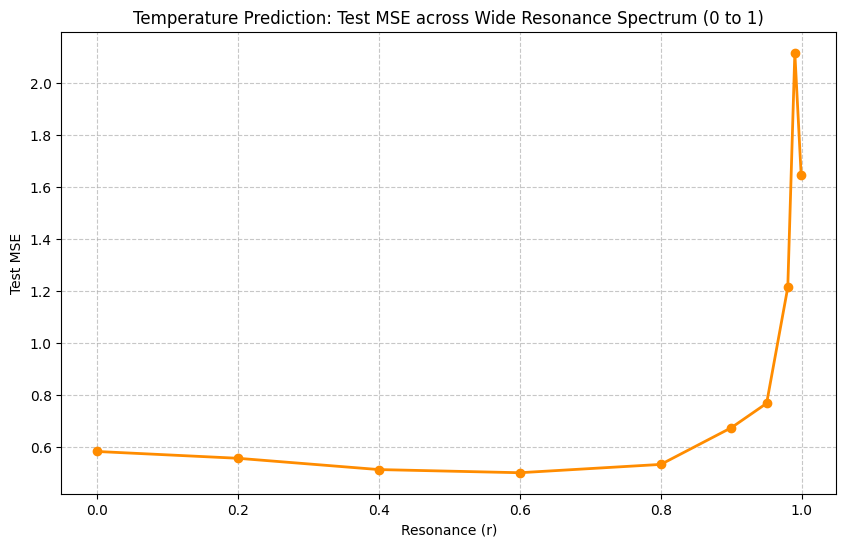

In [15]:
# Plot performance vs wide resonance values
plt.figure(figsize=(10, 6))
plt.plot(r_wide_sweep, wide_test_errors, marker="o", color="darkorange", linewidth=2)
plt.xlabel("Resonance (r)")
plt.ylabel("Test MSE")
plt.title("Temperature Prediction: Test MSE across Wide Resonance Spectrum (0 to 1)")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()